<a href="https://colab.research.google.com/github/balloontip/deep-learning/blob/main/chapter-08/08-07-RNN-Mixed-Input-Energy-Usage-Prediction-Project.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Goal: Build, train, and evaluate a mixed-input recurrent neural network (RNN) in PyTorch that predicts the next day's energy usage from a sequence of numerical temperature values and categorical day-of-week information. This end-to-end project demonstrates synthetic time-series generation, feature normalization, sequence creation, learned embeddings for categorical inputs, combining numerical and embedded features within an RNN, regression with Mean Squared Error (MSE) loss and the Adam optimizer, training-loss visualization, model evaluation, denormalization of predictions, and inference on previously unseen input sequences.

/tmp/ipykernel_1080/1450967455.py:71: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_temp = torch.tensor(X_temp_sequences, dtype=torch.float32).unsqueeze(-1)


--- Training Data Overview ---
X_temp shape: torch.Size([997, 3, 1])
X_day_of_week shape: torch.Size([997, 3])
Y_energy shape: torch.Size([997, 1])

First temperature sequence:
tensor([ 0.1249, -0.1261,  0.2343])

First day-of-week sequence:
tensor([0, 1, 2])

First target energy value:
0.24167650938034058
------------------------------

Mixed Input RNN Model Architecture:
MixedInputRNN(
  (day_embedding): Embedding(7, 5)
  (rnn): RNN(6, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
------------------------------

Starting Mixed Input RNN Training...
Epoch [100/1000], Loss: 0.3327
Epoch [200/1000], Loss: 0.2968
Epoch [300/1000], Loss: 0.2723
Epoch [400/1000], Loss: 0.2668
Epoch [500/1000], Loss: 0.2637
Epoch [600/1000], Loss: 0.2613
Epoch [700/1000], Loss: 0.2591
Epoch [800/1000], Loss: 0.2570
Epoch [900/1000], Loss: 0.2550
Epoch [1000/1000], Loss: 0.2527

Mixed Input RNN Training Complete.


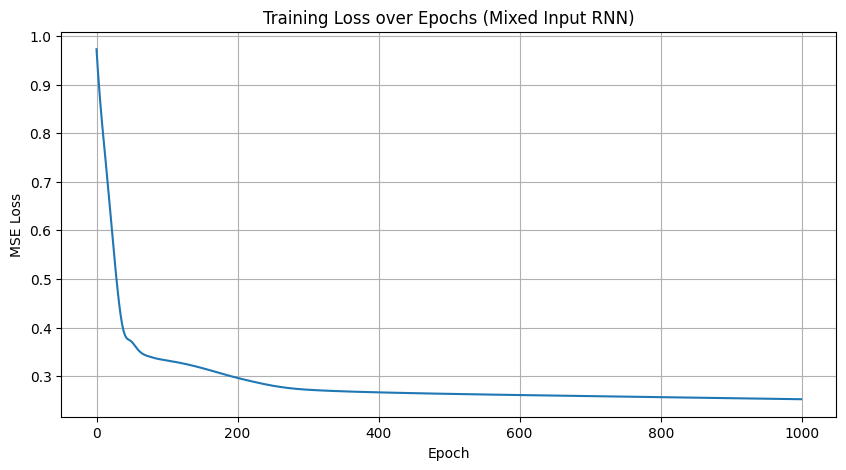


--- Mixed Input Model Predictions vs. Actual Values ---
Input Temps=[72.5 69.6 73.8], Days=[0 1 2] -> Actual: 74.96, Predicted: 70.21
Input Temps=[69.6 73.8 78.4], Days=[1 2 3] -> Actual: 69.39, Predicted: 73.65
Input Temps=[73.8 78.4 69.9], Days=[2 3 4] -> Actual: 61.02, Predicted: 67.27
Input Temps=[78.4 69.9 70.1], Days=[3 4 5] -> Actual: 70.79, Predicted: 65.16
Input Temps=[69.9 70.1 79.4], Days=[4 5 6] -> Actual: 73.92, Predicted: 71.84
Input Temps=[70.1 79.4 75.6], Days=[5 6 0] -> Actual: 70.26, Predicted: 74.30
Input Temps=[79.4 75.6 69.7], Days=[6 0 1] -> Actual: 71.60, Predicted: 73.46
Input Temps=[75.6 69.7 75. ], Days=[0 1 2] -> Actual: 70.83, Predicted: 71.81
Input Temps=[69.7 75.  70.3], Days=[1 2 3] -> Actual: 69.24, Predicted: 70.95
Input Temps=[75.  70.3 70.5], Days=[2 3 4] -> Actual: 66.88, Predicted: 62.34

Prediction for new 3-day sequence:
Temperatures=[82. 85. 83.], Days=[3 4 5]
Predicted next-day energy usage: 76.78


In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# For reproducible results
np.random.seed(42)
torch.manual_seed(42)

# --- 1. Prepare the Training Data ---
# Training data consists of simulated daily temperatures, day-of-week categories,
# and corresponding daily energy usage.
# The model learns to predict the next day's energy usage based on the previous
# 3 days of temperatures and days of the week.

# Define the number of days for our simulation.
num_days = 1000

# Use the previous 3 days to predict the next day's energy usage.
sequence_length = 3

# Generate a realistic seasonal temperature pattern with noise.
days = np.arange(num_days)
seasonal_temperature = 70 + 15 * np.sin(2 * np.pi * days / 365)
temperatures = seasonal_temperature + np.random.normal(0, 5, num_days)

# Generate the day of the week (0=Mon, 1=Tue, ..., 6=Sun) for each day.
day_of_week = days % 7

# Create a more realistic energy usage pattern.
# Energy increases on very hot days due to cooling,
# increases on very cold days due to heating,
# and is higher on weekdays than weekends.
cooling_demand = np.maximum(temperatures - 72, 0) * 1.2
heating_demand = np.maximum(60 - temperatures, 0) * 0.9
weekday_effect = (day_of_week < 5) * 8
seasonal_effect = 5 * np.sin(2 * np.pi * days / 365)

energy_usage = (
    60
    + cooling_demand
    + heating_demand
    + weekday_effect
    + seasonal_effect
    + np.random.normal(0, 1.5, num_days)
)

# Normalize temperature and energy usage for more stable training.
temp_mean = temperatures.mean()
temp_std = temperatures.std()
energy_mean = energy_usage.mean()
energy_std = energy_usage.std()

temperatures_norm = (temperatures - temp_mean) / temp_std
energy_usage_norm = (energy_usage - energy_mean) / energy_std

# Prepare sequences for the RNN.
# Input: previous 3 days of temperatures and day-of-week IDs.
# Target: the next day's energy usage.
X_temp_sequences = []
X_day_sequences = []
Y_energy_targets = []

for i in range(num_days - sequence_length):
    X_temp_sequences.append(temperatures_norm[i:i + sequence_length])
    X_day_sequences.append(day_of_week[i:i + sequence_length])
    Y_energy_targets.append(energy_usage_norm[i + sequence_length])

X_temp = torch.tensor(X_temp_sequences, dtype=torch.float32).unsqueeze(-1)
X_day_of_week = torch.tensor(X_day_sequences, dtype=torch.long)
Y_energy = torch.tensor(Y_energy_targets, dtype=torch.float32).unsqueeze(-1)

# Print out the shape and first training example.
print("--- Training Data Overview ---")
print(f"X_temp shape: {X_temp.shape}")                    # (num_samples, sequence_length, 1)
print(f"X_day_of_week shape: {X_day_of_week.shape}")      # (num_samples, sequence_length)
print(f"Y_energy shape: {Y_energy.shape}")                # (num_samples, 1)

print("\nFirst temperature sequence:")
print(X_temp[0].squeeze())

print("\nFirst day-of-week sequence:")
print(X_day_of_week[0])

print("\nFirst target energy value:")
print(Y_energy[0].item())
print("-" * 30)

# --- 2. Build the RNN Model with Categorical Embeddings ---
class MixedInputRNN(nn.Module):
    def __init__(self, temp_input_size, num_days_of_week, day_embedding_dim, hidden_size, output_size):
        """
        Initializes the MixedInputRNN model.

        Args:
            temp_input_size (int): Size of the numerical input, 1 for temperature.
            num_days_of_week (int): Number of day-of-week categories, 7.
            day_embedding_dim (int): Size of the embedding vector for each day.
            hidden_size (int): Number of features in the RNN hidden state.
            output_size (int): Size of the output, 1 for energy prediction.
        """
        super(MixedInputRNN, self).__init__()
        self.hidden_size = hidden_size

        # Embedding layer for the day-of-week categorical input.
        # It maps each day ID (0 to 6) to a learned dense vector.
        self.day_embedding = nn.Embedding(num_days_of_week, day_embedding_dim)

        # Total input size = temperature feature + day-of-week embedding.
        total_input_for_rnn = temp_input_size + day_embedding_dim

        # RNN processes the combined sequence.
        # Input shape: (batch_size, sequence_length, total_input_for_rnn)
        self.rnn = nn.RNN(total_input_for_rnn, hidden_size, batch_first=True)

        # Final output layer for regression.
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, temp_input, day_input):
        """
        Defines the forward pass.

        Args:
            temp_input (Tensor): Temperature sequence.
                Shape: (batch_size, sequence_length, 1)
            day_input (Tensor): Day-of-week ID sequence.
                Shape: (batch_size, sequence_length)

        Returns:
            Tensor: Predicted next-day energy usage.
                Shape: (batch_size, 1)
        """
        # Convert each day ID into its learned embedding vector.
        # Shape: (batch_size, sequence_length, day_embedding_dim)
        embedded_day = self.day_embedding(day_input)

        # Concatenate temperature and day embedding at each time step.
        # temp_input shape:   (batch_size, sequence_length, 1)
        # embedded_day shape: (batch_size, sequence_length, day_embedding_dim)
        # combined shape:     (batch_size, sequence_length, 1 + day_embedding_dim)
        combined_input = torch.cat((temp_input, embedded_day), dim=2)

        # Initialize the hidden state with zeros.
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(1, combined_input.size(0), self.hidden_size).to(combined_input.device)

        # Pass the combined sequence through the RNN.
        out, _ = self.rnn(combined_input, h0)

        # Use the final time step's output for the prediction.
        final_output = self.fc(out[:, -1, :])
        return final_output

# Model parameters for our mixed-input energy predictor.
temp_input_size = 1
num_days_of_week = 7
day_embedding_dim = 5
hidden_size_mixed = 32
output_size_mixed = 1

# Instantiate the model.
model_mixed = MixedInputRNN(
    temp_input_size,
    num_days_of_week,
    day_embedding_dim,
    hidden_size_mixed,
    output_size_mixed
)

criterion_mixed = nn.MSELoss()
optimizer_mixed = optim.Adam(model_mixed.parameters(), lr=0.001)

print("\nMixed Input RNN Model Architecture:")
print(model_mixed)
print("-" * 30)

# --- 3. Training ---
num_epochs_mixed = 1000

print("\nStarting Mixed Input RNN Training...")
losses_mixed = []

for epoch in range(num_epochs_mixed):
    model_mixed.train()
    optimizer_mixed.zero_grad()

    predictions_mixed = model_mixed(X_temp, X_day_of_week)
    loss_mixed = criterion_mixed(predictions_mixed, Y_energy)

    loss_mixed.backward()
    optimizer_mixed.step()

    losses_mixed.append(loss_mixed.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs_mixed}], Loss: {loss_mixed.item():.4f}")

print("\nMixed Input RNN Training Complete.")

# Plot the training loss.
plt.figure(figsize=(10, 5))
plt.plot(losses_mixed)
plt.title("Training Loss over Epochs (Mixed Input RNN)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# --- 4. Evaluation ---
model_mixed.eval()

with torch.no_grad():
    predicted_energy_norm = model_mixed(X_temp, X_day_of_week).numpy()

# Convert predictions and targets back to the original energy scale.
predicted_energy = predicted_energy_norm * energy_std + energy_mean
actual_energy = Y_energy.numpy() * energy_std + energy_mean

print("\n--- Mixed Input Model Predictions vs. Actual Values ---")
for i in range(10):
    original_temp_sequence = (X_temp[i].squeeze().numpy() * temp_std) + temp_mean
    day_sequence = X_day_of_week[i].numpy()

    print(
        f"Input Temps={np.round(original_temp_sequence, 1)}, "
        f"Days={day_sequence} -> "
        f"Actual: {actual_energy[i].item():.2f}, "
        f"Predicted: {predicted_energy[i].item():.2f}"
    )

# Example prediction for a new, unseen 3-day scenario.
new_temp_sequence = np.array([82, 85, 83], dtype=np.float32)
new_day_sequence = np.array([3, 4, 5], dtype=np.int64)  # Thu, Fri, Sat

# Normalize the new temperature sequence using the training data statistics.
new_temp_sequence_norm = (new_temp_sequence - temp_mean) / temp_std

new_temp = torch.tensor(new_temp_sequence_norm, dtype=torch.float32).view(1, sequence_length, 1)
new_day = torch.tensor(new_day_sequence, dtype=torch.long).view(1, sequence_length)

with torch.no_grad():
    predicted_new_energy_norm = model_mixed(new_temp, new_day).item()

predicted_new_energy = predicted_new_energy_norm * energy_std + energy_mean

print(
    f"\nPrediction for new 3-day sequence:\n"
    f"Temperatures={new_temp_sequence}, Days={new_day_sequence}\n"
    f"Predicted next-day energy usage: {predicted_new_energy:.2f}"
)
